# 01 — Exploratory Data Analysis
Phase 2: EDA only — no preprocessing, no modeling. Dataset: UCI Default of Credit Card Clients (30,000 rows).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../src')
from load_data import load_raw_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

TARGET = "default.payment.next.month"

df = load_raw_data()
df.shape

(30000, 25)

## 1. Target distribution
Confirming the known class imbalance visually.

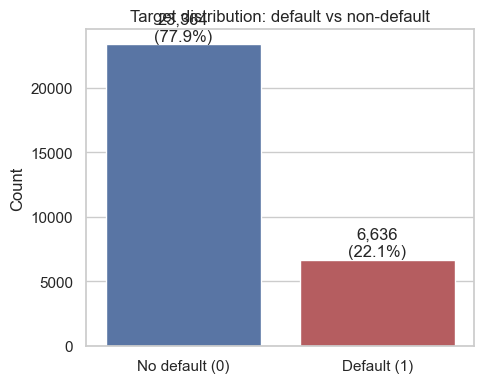

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [2]:
counts = df[TARGET].value_counts().sort_index()
rates = df[TARGET].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=["No default (0)", "Default (1)"], y=counts.values, hue=["No default (0)", "Default (1)"],
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f"{v:,}\n({rates.values[i]:.1%})", ha="center")
ax.set_ylabel("Count")
ax.set_title("Target distribution: default vs non-default")
plt.tight_layout()
plt.show()

print(rates)

**Interpretation:** Non-defaulters make up 77.88% of the dataset versus 22.12% defaulters, matching the expected imbalance for this dataset. This is a meaningful imbalance — any model built later needs class weighting, resampling, or threshold tuning, and plain accuracy will be a misleading metric.

## 2. Credit limit (`LIMIT_BAL`) vs default
Does the credit limit issued differ between people who default and people who don't?

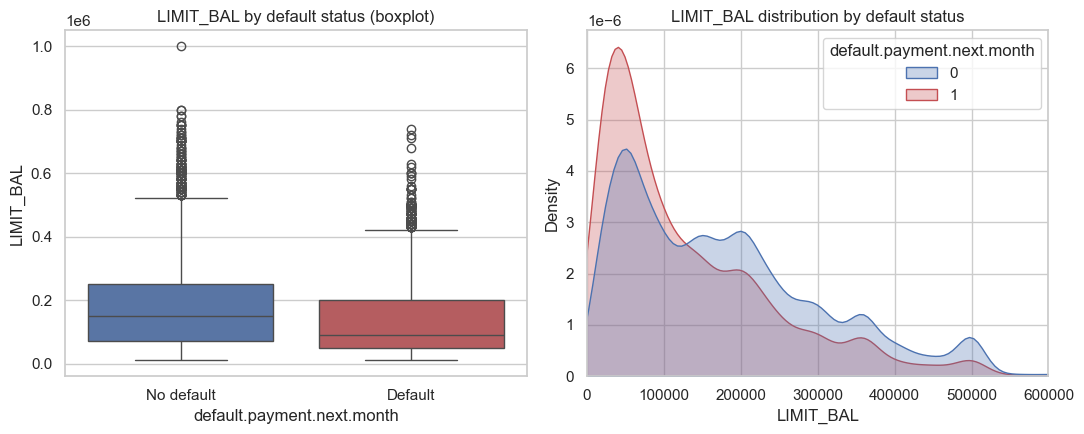

default.payment.next.month
0    150000.0
1     90000.0
Name: LIMIT_BAL, dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df, x=TARGET, y="LIMIT_BAL", hue=TARGET, palette=["#4C72B0", "#C44E52"], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No default", "Default"])
axes[0].set_title("LIMIT_BAL by default status (boxplot)")

sns.kdeplot(data=df, x="LIMIT_BAL", hue=TARGET, common_norm=False, fill=True, alpha=0.3,
            palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("LIMIT_BAL distribution by default status")
axes[1].set_xlim(0, 600000)

plt.tight_layout()
plt.show()

df.groupby(TARGET)["LIMIT_BAL"].median()

**Interpretation:** Defaulters have a noticeably lower median credit limit than non-defaulters, and the non-default group's distribution is shifted toward higher limits. This makes sense — banks extend larger limits to lower-risk customers — so `LIMIT_BAL` carries real (if modest) separating signal, not a dramatic one.

## 3. Age vs default
Bucketing `AGE` into decades and computing the default rate per bucket.

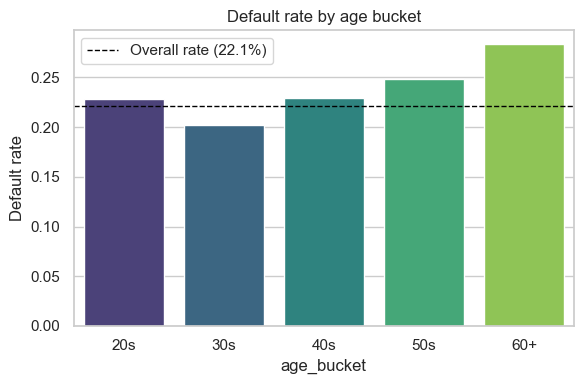

age_bucket
20s    0.228426
30s    0.202527
40s    0.229734
50s    0.248612
60+    0.283186
Name: default.payment.next.month, dtype: float64

In [4]:
bins = [20, 30, 40, 50, 60, 100]
labels = ["20s", "30s", "40s", "50s", "60+"]
df["age_bucket"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

age_rate = df.groupby("age_bucket", observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=age_rate.index, y=age_rate.values, hue=age_rate.index, palette="viridis", legend=False, ax=ax)
ax.axhline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1, label="Overall rate (22.1%)")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by age bucket")
ax.legend()
plt.tight_layout()
plt.show()

age_rate

**Interpretation:** Default rate is relatively flat across age buckets, with the 20s and 60+ groups running slightly above the 22.1% baseline and the 30s/40s slightly below. Age has some effect but it's small compared to the variation we'll see in repayment history — it's a weak, second-order signal at best.

## 4. Repayment status (`PAY_0`–`PAY_6`) vs default
For each repayment-status column, default rate by status value. Hypothesis: this is the strongest predictor in the dataset.

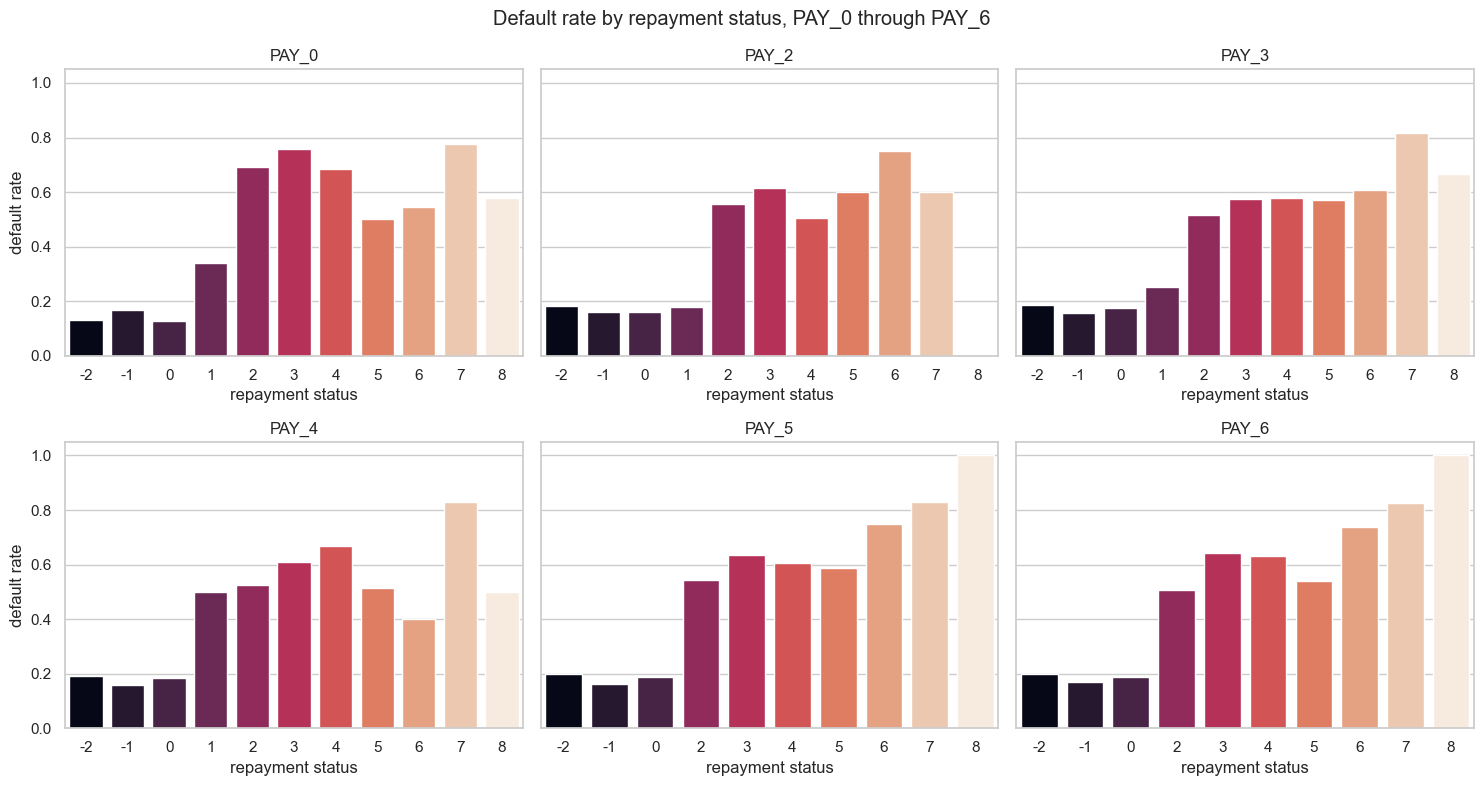

PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default.payment.next.month, dtype: float64

In [5]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, col in zip(axes.flat, pay_cols):
    rate = df.groupby(col)[TARGET].mean()
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette="rocket", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("repayment status")
    ax.set_ylabel("default rate")

plt.suptitle("Default rate by repayment status, PAY_0 through PAY_6")
plt.tight_layout()
plt.show()

df.groupby("PAY_0")[TARGET].mean()

**Interpretation:** Default rate climbs sharply as `PAY_0` (most recent repayment status) moves from on-time/no-delay (-2, -1, 0) into 1+ months delinquent, reaching well above 50% at 2+ months late — versus roughly the baseline rate for accounts that paid on time. The same pattern holds, slightly weaker, for `PAY_2` through `PAY_6`. This **confirms** the hypothesis: recent repayment status is the strongest predictor of default in this dataset, by a wide margin over `LIMIT_BAL` or `AGE`.

## 5. Correlation heatmap
General numeric correlation heatmap, then correlation with the target isolated separately so the strongest linear relationships aren't buried in a 24x24 grid.

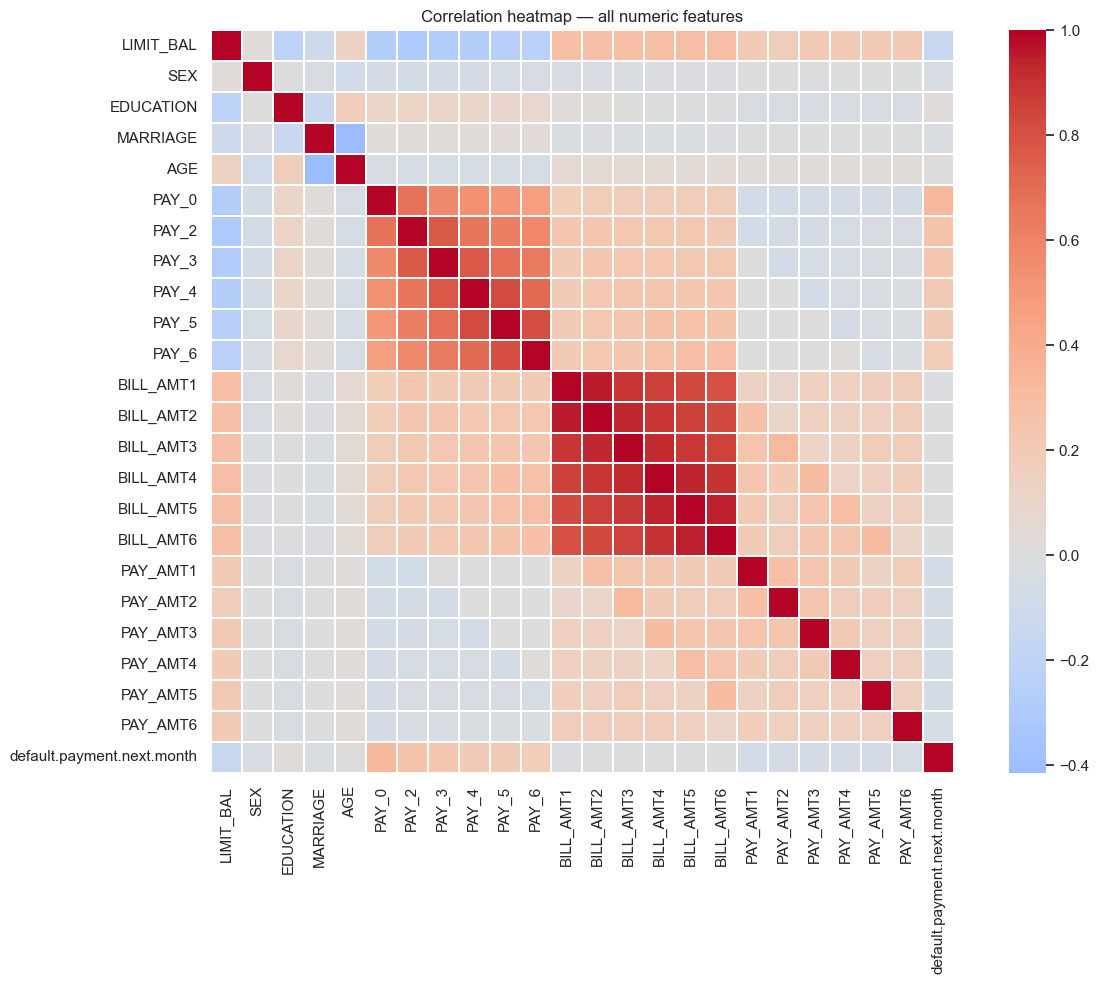

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["ID"]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, ax=ax)
ax.set_title("Correlation heatmap — all numeric features")
plt.tight_layout()
plt.show()

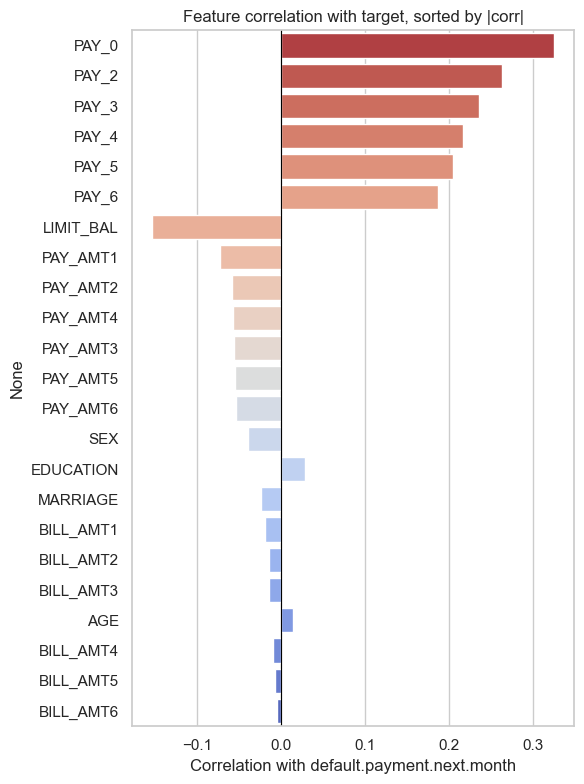

PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default.payment.next.month, dtype: float64

In [7]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="coolwarm_r", legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with default.payment.next.month")
ax.set_title("Feature correlation with target, sorted by |corr|")
plt.tight_layout()
plt.show()

target_corr

**Interpretation:** The `PAY_0`–`PAY_6` repayment-status columns dominate the correlation ranking (`PAY_0` highest at roughly +0.32), confirming what the bucketed chart above showed directly. `LIMIT_BAL` is the strongest negative correlate (higher limit, lower default risk) but at a much smaller magnitude. Bill and payment amounts correlate weakly with the target — on their own they're not doing much predictive work.

## 6. Bill amount and payment amount distributions
Checking `BILL_AMT1-6` and `PAY_AMT1-6` for skew and outliers that later preprocessing will need to address.

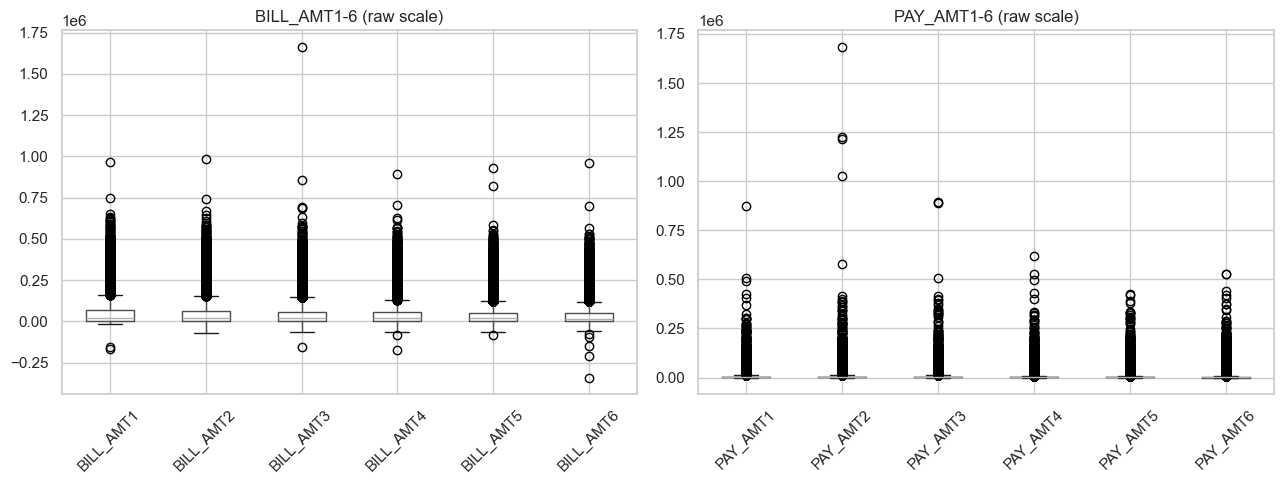

,skew,min,max
BILL_AMT1,2.663861,-165580.0,964511.0
BILL_AMT2,2.705221,-69777.0,983931.0
BILL_AMT3,3.087830,-157264.0,1664089.0
BILL_AMT4,2.821965,-170000.0,891586.0
BILL_AMT5,2.876380,-81334.0,927171.0
BILL_AMT6,2.846645,-339603.0,961664.0
PAY_AMT1,14.668364,0.0,873552.0
PAY_AMT2,30.453817,0.0,1684259.0
PAY_AMT3,17.216635,0.0,896040.0
PAY_AMT4,12.904985,0.0,621000.0


In [8]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df[bill_cols].boxplot(ax=axes[0], rot=45)
axes[0].set_title("BILL_AMT1-6 (raw scale)")

df[pay_amt_cols].boxplot(ax=axes[1], rot=45)
axes[1].set_title("PAY_AMT1-6 (raw scale)")

plt.tight_layout()
plt.show()

df[bill_cols + pay_amt_cols].agg(["skew", "min", "max"]).T

**Interpretation:** Both groups are heavily right-skewed with long tails of high-value outliers, and `BILL_AMT` columns also contain negative values (credit balances) that widen their range further. `PAY_AMT` skew is more extreme than `BILL_AMT` — a handful of very large one-off payments dominate the scale. Preprocessing will need a log transform or robust scaling on these columns rather than raw min-max scaling.

## 7. Categorical breakdowns — SEX, EDUCATION, MARRIAGE vs default rate
*Tagged for reuse in the Phase 5 fairness audit.* Quick default-rate comparison across demographic categories.

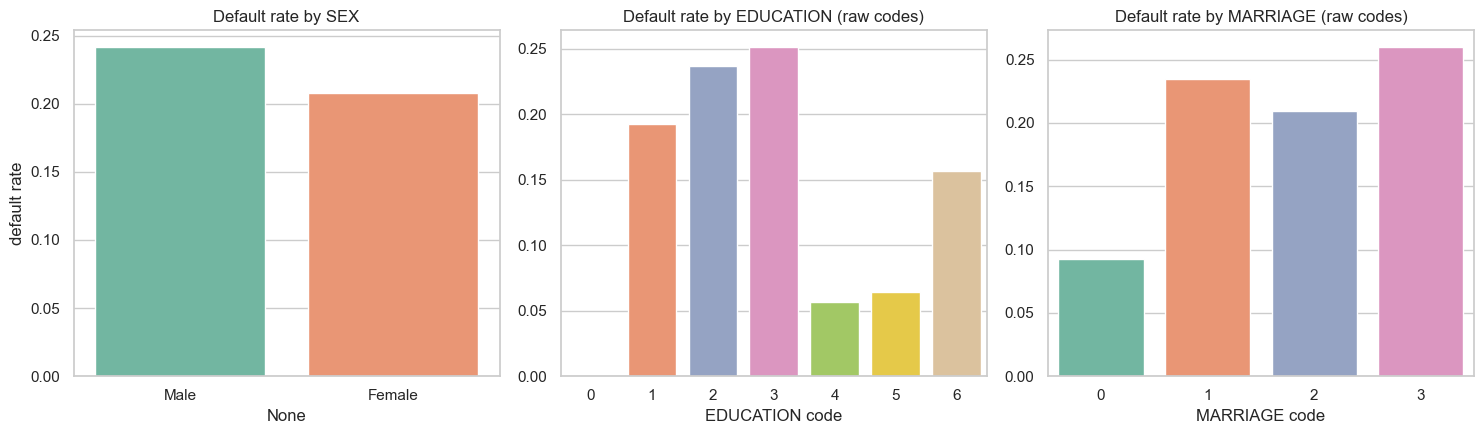

SEX:
 Male      0.241672
Female    0.207763
Name: default.payment.next.month, dtype: float64 

EDUCATION:
 EDUCATION
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: default.payment.next.month, dtype: float64 

MARRIAGE:
 MARRIAGE
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: default.payment.next.month, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sex_rate = df.groupby("SEX")[TARGET].mean()
sex_rate.index = ["Male", "Female"]
sns.barplot(x=sex_rate.index, y=sex_rate.values, hue=sex_rate.index, palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Default rate by SEX")
axes[0].set_ylabel("default rate")

edu_rate = df.groupby("EDUCATION")[TARGET].mean()
sns.barplot(x=edu_rate.index, y=edu_rate.values, hue=edu_rate.index, palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Default rate by EDUCATION (raw codes)")
axes[1].set_xlabel("EDUCATION code")

mar_rate = df.groupby("MARRIAGE")[TARGET].mean()
sns.barplot(x=mar_rate.index, y=mar_rate.values, hue=mar_rate.index, palette="Set2", legend=False, ax=axes[2])
axes[2].set_title("Default rate by MARRIAGE (raw codes)")
axes[2].set_xlabel("MARRIAGE code")

plt.tight_layout()
plt.show()

print("SEX:\n", sex_rate, "\n")
print("EDUCATION:\n", edu_rate, "\n")
print("MARRIAGE:\n", mar_rate)

**Interpretation:** Default rate differs modestly by sex (male somewhat higher than female) and by education and marital status codes, but no category shows the kind of large gap that `PAY_0` shows. These differences are exactly the kind of demographic disparity the Phase 5 fairness audit needs to check aren't amplified — or driven — by the model, since `EDUCATION`/`MARRIAGE` include undocumented codes (0, 5, 6 / 0) worth flagging for cleanup before that stage.

## EDA Summary

- **Repayment history is king.** Recent repayment status (`PAY_0` especially) is by far the strongest predictor of default — default rate jumps from roughly baseline for on-time accounts to 50%+ once a customer is 2+ months delinquent.
- **Credit limit matters, moderately.** Customers with lower `LIMIT_BAL` default more often, consistent with banks already pricing risk into the limits they issue — useful signal, but far weaker than repayment status.
- **Age is a weak signal.** Default rate is roughly flat across age brackets, with only slightly elevated risk in the youngest (20s) and oldest (60+) groups.
- **Bill and payment amounts are noisy, skewed, and only weakly correlated with default on their own** — they'll need log/robust transforms before modeling, and may matter more as derived features (e.g. payment-to-bill ratios) than as raw values.
- **Demographics (sex, education, marriage) show only modest default-rate differences** — worth tracking carefully in the Phase 5 fairness audit, and `EDUCATION`/`MARRIAGE` contain undocumented category codes that need cleanup before modeling.
- **Class imbalance (22.1% default) is real and must be handled explicitly** in any model — accuracy alone will be a misleading metric.